# 5. Сортировка

### 5.1 Пузырьковая сортировка

In [1]:
def bubble(arr):
    n = len(arr)
    for i in range(n):
        print(arr)
        zamena = False
        for j in range(n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                zamena = True
        if zamena == False:
            break
    return arr

In [2]:
l = [1,5,8,9,7,6,4,3,2,0]
bubble(l)

[1, 5, 8, 9, 7, 6, 4, 3, 2, 0]
[1, 5, 8, 7, 6, 4, 3, 2, 0, 9]
[1, 5, 7, 6, 4, 3, 2, 0, 8, 9]
[1, 5, 6, 4, 3, 2, 0, 7, 8, 9]
[1, 5, 4, 3, 2, 0, 6, 7, 8, 9]
[1, 4, 3, 2, 0, 5, 6, 7, 8, 9]
[1, 3, 2, 0, 4, 5, 6, 7, 8, 9]
[1, 2, 0, 3, 4, 5, 6, 7, 8, 9]
[1, 0, 2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

### 5.2 Быстрая сортировка

In [3]:
def quick(arr, pIndex):
    #print(arr)
    if len(arr) <= 1:
        return arr
    if pIndex == 0:
        base = arr[0]
    elif pIndex == 1:
        base = arr[len(arr) // 2]
    elif pIndex == 2:
        base = arr[-1]
    left = [x for x in arr if x < base]
    middle = [x for x in arr if x == base]
    right = [x for x in arr if x > base]
    return quick(left, pIndex) + middle + quick(right, pIndex)

In [4]:
l = [1,5,8,9,7,6,4,3,2,0]
quick(l,2)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

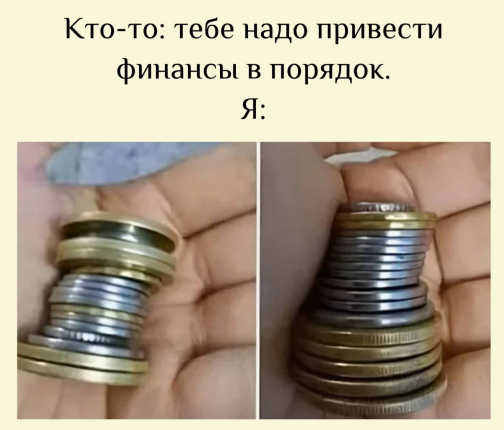

In [5]:
l = [1,5,8,9,7,6,4,3,2,0]
l.sort()
print(l)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [6]:
l = [1,5,8,9,7,6,4,3,2,0]
l1 = sorted(l)
print(l, '\n', l1)

[1, 5, 8, 9, 7, 6, 4, 3, 2, 0] 
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


# Задание
### 1. Изучить функции с реализацией сортировки
### 2. Изучить проведение сортировки различными способами и сделать вывод об алгоритмической сложности. Проверить на массивах различного объема (10, 10_000, 10_000_000 элементов). Для быстрой сортировки проверить зависимость времени выполнения задачи от выбора базового элемента.
### 3. Сравнить самописные методы сортировки с sorted() и .sort()
### *4. **Кейс:** Оптимизация вывода данных в интернет-магазине по цене и популярности.

In [7]:
def bubbleSort(arr):
    print(arr)
    if len(arr) <=1:
        return arr
    for i in range(len(arr)):
        for j in range(0, len(arr)-i-1):
            if arr[j]>arr[j+1]:
                arr[j], arr[j+1]=arr[j+1], arr[j]
    return arr

def divide(arr, low, high):
    pivot = arr[high] 
    i = low - 1 
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

def quickSort(arr, low=0, high=None):
    if high is None:
        high = len(arr) - 1 

    if low < high:
        pivot_index = divide(arr, low, high)
        quickSort(arr, low, pivot_index - 1)  
        quickSort(arr, pivot_index + 1, high)  

    return arr

In [8]:
import random as rand
import timeit

no_sort_10 = [rand.randint(0, 100) for _ in range(10)]
no_sort_10K = [rand.randint(0, 100) for _ in range(10**4)]
no_sort_1M = [rand.randint(0, 100) for _ in range(10**6)]
no_sort = [no_sort_10,no_sort_10K,no_sort_1M]
methods = [0,1,2]
sorted = quick(no_sort[0], methods[0])
execution_time = timeit.timeit(lambda: quick(no_sort_10K, 0), number=1000)
print(f"Среднее время: {execution_time / 1000:.6f} секунд")

Среднее время: 0.007040 секунд


In [9]:
#Для 10 элементов
for i in range(len(methods)):
    execution_time = timeit.timeit(lambda: quick(no_sort[0], methods[i]), number=1000)
    print(f"Среднее время: {execution_time / 1000:.6f} секунд, метод: {methods[i]}")

Среднее время: 0.000014 секунд, метод: 0
Среднее время: 0.000009 секунд, метод: 1
Среднее время: 0.000010 секунд, метод: 2


In [10]:
#Для 10K элементов
for i in range(len(methods)):
    execution_time = timeit.timeit(lambda: quick(no_sort[1], methods[i]), number=1000)
    print(f"Среднее время: {execution_time / 1000:.6f} секунд, метод: {methods[i]}")

Среднее время: 0.006884 секунд, метод: 0
Среднее время: 0.008262 секунд, метод: 1
Среднее время: 0.007508 секунд, метод: 2


In [11]:
#Для 1M элементов
'''for i in range(len(methods)):
    execution_time = timeit.timeit(lambda: quick(no_sort[2], methods[i]), number=1000)
    print(f"Среднее время: {execution_time / 1000:.6f} секунд, метод: {methods[i]}")'''

'for i in range(len(methods)):\n    execution_time = timeit.timeit(lambda: quick(no_sort[2], methods[i]), number=1000)\n    print(f"Среднее время: {execution_time / 1000:.6f} секунд, метод: {methods[i]}")'

In [17]:
#Для 10 элементов
execution_time = timeit.timeit(lambda: no_sort[0].sort(), number=1000)
print(f"Среднее время: {execution_time / 1000:.6f} секунд")

Среднее время: 0.000000 секунд


In [18]:
#Для 10K элементов
execution_time = timeit.timeit(lambda: no_sort[1].sort(), number=1000)
print(f"Среднее время: {execution_time / 1000:.6f} секунд")
print(no_sort[0].sort)

Среднее время: 0.000067 секунд
<built-in method sort of list object at 0x00000292016649C0>


In [19]:
#Для 1M элементов
execution_time = timeit.timeit(lambda: no_sort[2].sort(), number=1000)
print(f"Среднее время: {execution_time / 1000:.6f} секунд")

Среднее время: 0.005317 секунд


#### Не удивительно, что встроенные методы sort намного быстрее самописных